In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv("Downloads/warehouse_inventory_clustering_dataset.csv")

In [3]:
df.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   item_id                          4000 non-null   object 
 1   category                         4000 non-null   object 
 2   subcategory                      4000 non-null   object 
 3   supplier_id                      4000 non-null   object 
 4   warehouse_zone                   4000 non-null   object 
 5   avg_monthly_demand               4000 non-null   int64  
 6   demand_variability               4000 non-null   float64
 7   avg_lead_time_days               4000 non-null   float64
 8   lead_time_variability            4000 non-null   float64
 9   monthly_reorder_count            4000 non-null   int64  
 10  stock_turnover_ratio             4000 non-null   float64
 11  days_in_inventory                4000 non-null   int64  
 12  stockout_frequency  

In [5]:
df.describe()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4000.00000
mean,331.809250,0.285640,10.301275,0.258738,4.707250,5.944282,65.489750,2.491250,1.938000,0.028485,0.015713,47.709973,804.380267,2.657250,3.239750,317.102000,80.002750,104.915750,2.491254e+05,159.10009
std,228.438284,0.128173,5.592473,0.165963,2.991118,3.804082,56.855528,3.192487,2.503642,0.015560,0.008412,50.174326,741.472968,3.498976,3.615873,136.958627,55.192937,106.302228,2.508303e+05,88.27321
min,1.000000,0.080000,1.000000,0.050000,0.000000,0.200000,4.000000,0.000000,0.000000,0.005000,0.002000,0.520000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000e+00,5.00000
25%,103.000000,0.190000,6.200000,0.130000,2.000000,2.140000,22.000000,0.000000,0.000000,0.017000,0.009000,12.565000,220.160000,0.000000,0.000000,219.000000,27.000000,32.000000,6.278350e+04,82.77000
50%,333.000000,0.260000,9.000000,0.200000,5.000000,6.150000,34.000000,1.000000,1.000000,0.026000,0.015000,33.710000,652.130000,1.000000,2.000000,304.000000,80.000000,60.000000,1.759532e+05,151.79500
75%,523.250000,0.370000,13.400000,0.360000,7.000000,9.140000,106.000000,4.000000,3.000000,0.037000,0.020000,64.495000,1108.817500,4.000000,5.000000,403.000000,122.000000,150.000000,3.498038e+05,228.21000
max,983.000000,0.620000,35.000000,0.720000,14.000000,15.890000,273.000000,15.000000,14.000000,0.080000,0.040000,502.570000,6085.330000,17.000000,18.000000,908.000000,306.000000,622.000000,2.093354e+06,300.00000


In [6]:
df.isnull().sum()

item_id                            0
category                           0
subcategory                        0
supplier_id                        0
warehouse_zone                     0
avg_monthly_demand                 0
demand_variability                 0
avg_lead_time_days                 0
lead_time_variability              0
monthly_reorder_count              0
stock_turnover_ratio               0
days_in_inventory                  0
stockout_frequency                 0
backorder_frequency                0
return_rate                        0
damage_rate                        0
holding_cost_per_unit              0
unit_cost                          0
reorder_point_breaches             0
supplier_delay_incidents           0
current_stock                      0
safety_stock                       0
excess_stock_level                 0
inventory_value                    0
warehouse_demand_pressure_index    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [12]:
drop_columns=[
    'item_id',
    'supplier_id',
    'subcategory',
    'days_in_inventory',
    'unit_cost',
    'holding_cost_per_unit',
    'reorder_point_breaches',
    'safety_stock'
]

In [13]:
categorical_columns=[
    'category',
    'warehouse_zone'
]

In [14]:
selected_numerical_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'lead_time_variability',
    'supplier_delay_incidents',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backorder_frequency',
    'inventory_value',
    'current_stock',
    'excess_stock_level',
    'return_rate',
    'damage_rate',
    'warehouse_demand_pressure_index'
]

In [15]:
df1=df.drop(columns=drop_columns)

In [16]:
df_encoded=pd.get_dummies(df1,columns=categorical_columns,drop_first=True)

In [17]:
X=df_encoded

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avg_monthly_demand               4000 non-null   int64  
 1   demand_variability               4000 non-null   float64
 2   avg_lead_time_days               4000 non-null   float64
 3   lead_time_variability            4000 non-null   float64
 4   monthly_reorder_count            4000 non-null   int64  
 5   stock_turnover_ratio             4000 non-null   float64
 6   stockout_frequency               4000 non-null   int64  
 7   backorder_frequency              4000 non-null   int64  
 8   return_rate                      4000 non-null   float64
 9   damage_rate                      4000 non-null   float64
 10  supplier_delay_incidents         4000 non-null   int64  
 11  current_stock                    4000 non-null   int64  
 12  excess_stock_level  

In [7]:
numcol = df.select_dtypes(include=['int64','float64']).columns.tolist()

In [20]:
X_scaled.shape

(4000, 29)

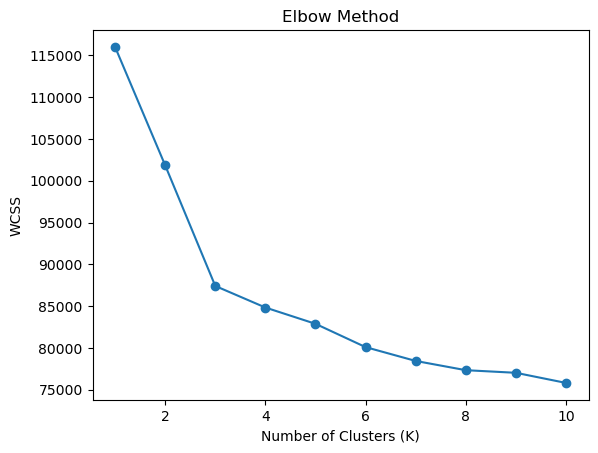

In [21]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [22]:
kmeans_3=KMeans(n_clusters=3,random_state=42)
df_encoded['Cluster_3']=kmeans_3.fit_predict(X_scaled)
kmeans_4=KMeans(n_clusters=4,random_state=42)
df_encoded['Cluster_4']=kmeans_4.fit_predict(X_scaled)

In [23]:
df_encoded.groupby('Cluster_3').mean()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,category_Pharmaceutical,category_Stationery,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_4
Cluster_3,,,,,,,,,,,,,,,,,,,,,
0,80.417761,0.321537,9.712046,0.214193,1.530502,1.678077,0.688803,0.591506,0.034103,0.019467,...,0.119691,0.119691,0.136680,0.126641,0.115058,0.135907,0.118919,0.115830,0.12278,0.023166
1,525.839744,0.180513,6.045655,0.117215,6.488604,9.190506,0.722934,0.695157,0.022284,0.011046,...,0.135328,0.119658,0.126068,0.108262,0.110399,0.145299,0.128917,0.131054,0.12037,1.005698
2,372.649500,0.363359,15.480323,0.455803,5.946964,6.687586,6.193697,4.619523,0.029584,0.017012,...,0.118370,0.131437,0.118370,0.134512,0.129131,0.127594,0.128363,0.119908,0.12452,2.467333


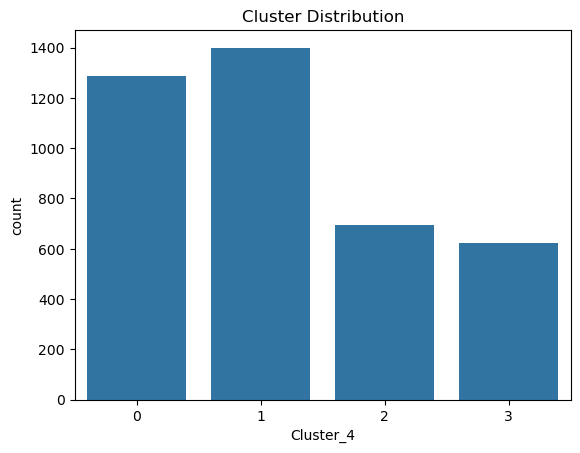

In [24]:
sns.countplot(x='Cluster_4',data=df_encoded)
plt.title("Cluster Distribution")
plt.show()


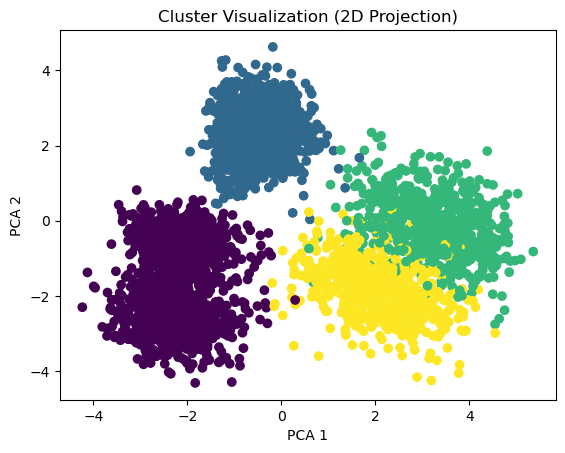

In [25]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['Cluster_4'])
plt.title('Cluster Visualization (2D Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [26]:
core_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backorder_frequency',
    'inventory_value',
    'warehouse_demand_pressure_index'
]

In [27]:
X_core=df_encoded[core_features]
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_scaled_core=scaler.fit_transform(X_core)

In [28]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=1.0,min_samples=10)
clusters=db.fit_predict(X_scaled_core)
df_encoded['DBSCAN_CLUSTER']=clusters


In [29]:
df_encoded['DBSCAN_CLUSTER'].value_counts()

DBSCAN_CLUSTER
 0    3814
-1     186
Name: count, dtype: int64

In [30]:
outliers=df_encoded[df_encoded['DBSCAN_CLUSTER']==-1]

In [31]:
outliers.mean(numeric_only=True)

avg_monthly_demand                    473.370968
demand_variability                      0.384247
avg_lead_time_days                     14.196774
lead_time_variability                   0.410000
monthly_reorder_count                   6.166667
stock_turnover_ratio                    7.610591
stockout_frequency                      6.354839
backorder_frequency                     5.419355
return_rate                             0.028898
damage_rate                             0.016586
supplier_delay_incidents                6.752688
current_stock                         400.731183
excess_stock_level                     58.112903
inventory_value                    548134.425860
warehouse_demand_pressure_index       222.695538
category_Automotive                     0.145161
category_Electronics                    0.150538
category_Grocery                        0.026882
category_Home & Kitchen                 0.123656
category_Industrial                     0.354839
category_Pharmaceuti

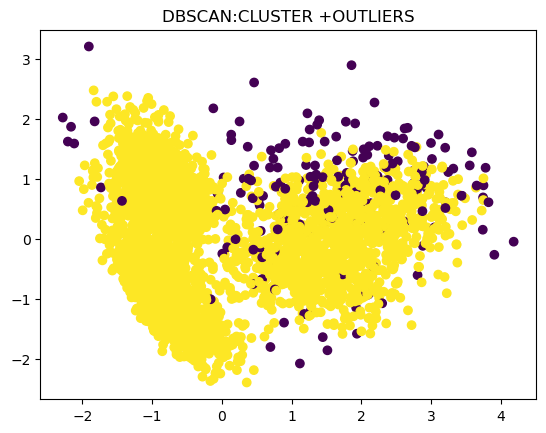

In [33]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled_core)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,-1],c=df_encoded['DBSCAN_CLUSTER'])
plt.title('DBSCAN:CLUSTER +OUTLIERS')# Title
plt.show()

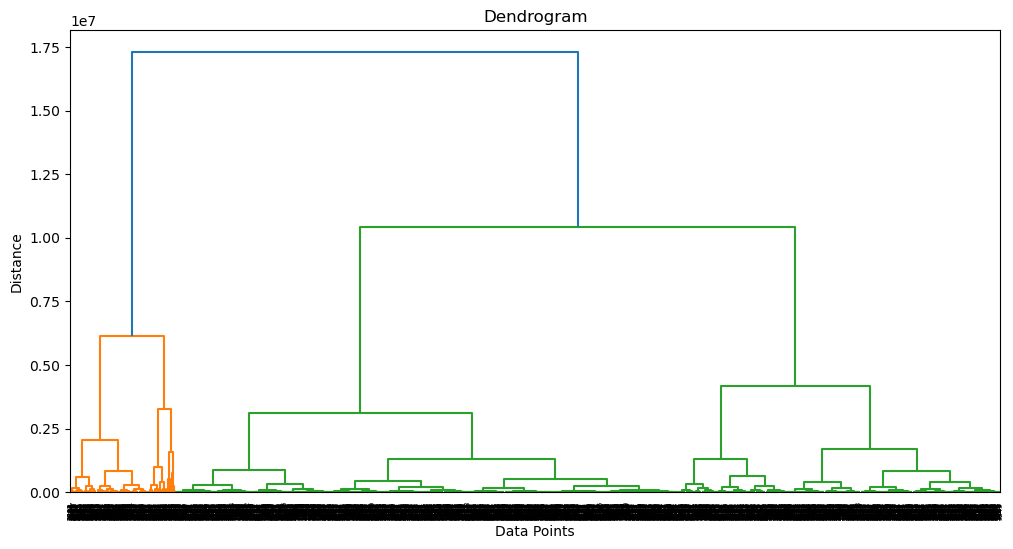

In [38]:
from scipy.cluster.hierarchy import dendrogram,linkage
linked=linkage(X,method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title('Dendrogram') 
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [39]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=4,linkage='ward')
clusters=hc.fit_predict(X)

In [40]:
df_encoded['HC_Cluster']=clusters

In [41]:
df_encoded['HC_Cluster'].value_counts()

HC_Cluster
2    2171
0    1381
3     337
1     111
Name: count, dtype: int64

In [42]:
df_encoded.groupby('HC_Cluster').mean(numeric_only=True)

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_3,Cluster_4,DBSCAN_CLUSTER
HC_Cluster,,,,,,,,,,,,,,,,,,,,,
0,359.507603,0.276307,9.839537,0.241224,4.805938,6.147495,2.233888,1.779870,0.027828,0.015185,...,0.128892,0.111513,0.116582,0.133961,0.126720,0.132513,0.128168,0.961622,1.078928,-0.046343
1,350.036036,0.247928,8.381081,0.188018,4.270270,5.311351,1.270270,1.153153,0.024261,0.013081,...,0.090090,0.171171,0.108108,0.135135,0.126126,0.171171,0.099099,0.540541,0.558559,-0.207207
2,301.921695,0.296564,10.907877,0.280129,4.648549,5.794169,2.798710,2.098572,0.029432,0.016342,...,0.130815,0.127130,0.116536,0.139567,0.124367,0.113772,0.116536,1.070014,1.285122,-0.016582
3,404.839763,0.265935,8.918101,0.215994,4.824926,6.287062,1.967359,1.810089,0.026463,0.014691,...,0.106825,0.124629,0.136499,0.127596,0.127596,0.121662,0.145401,0.875371,0.919881,-0.186944


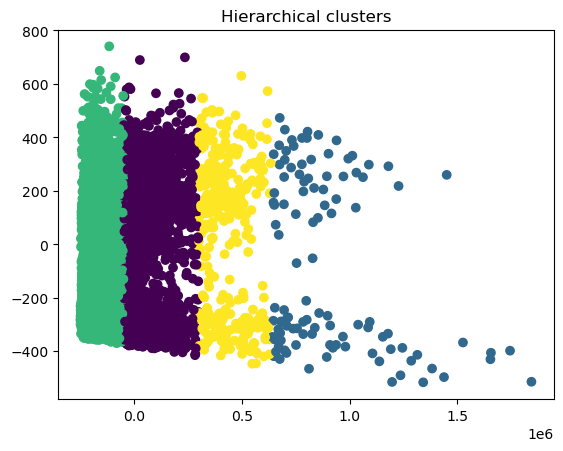

In [43]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['HC_Cluster'])
plt.title('Hierarchical clusters')
plt.show()

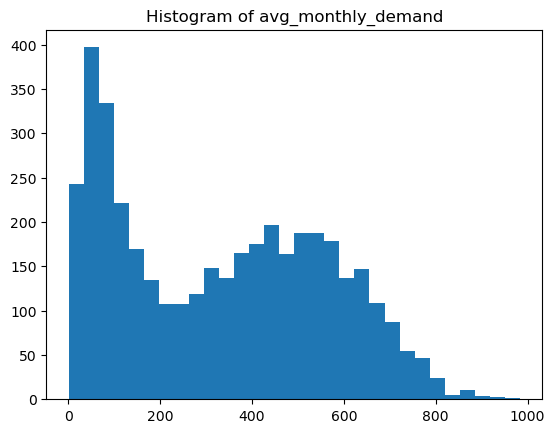

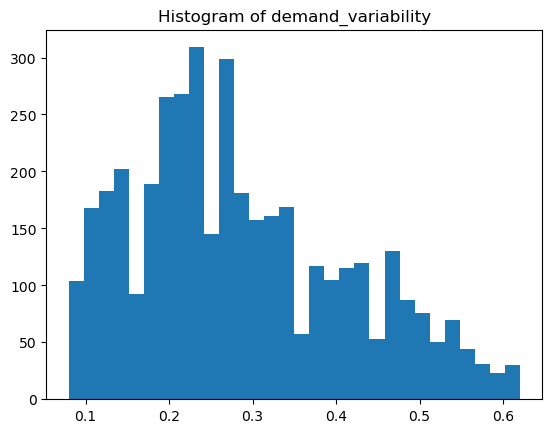

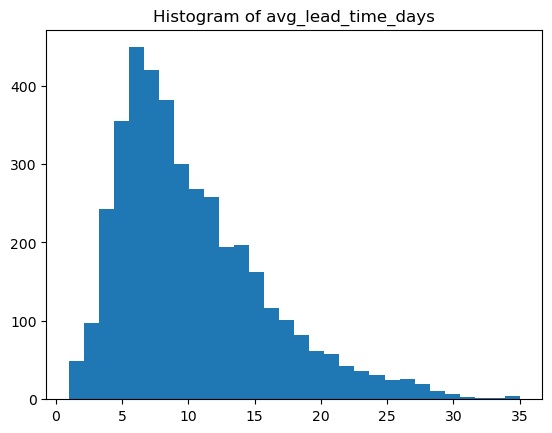

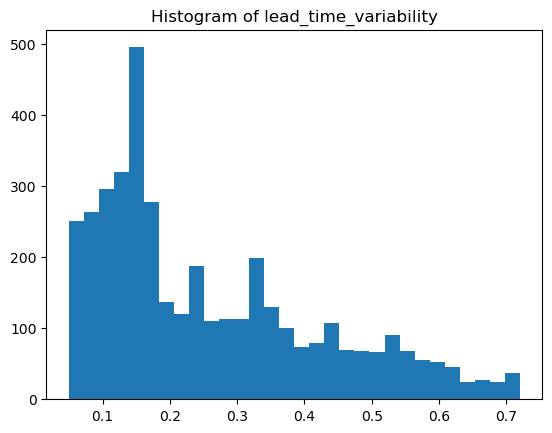

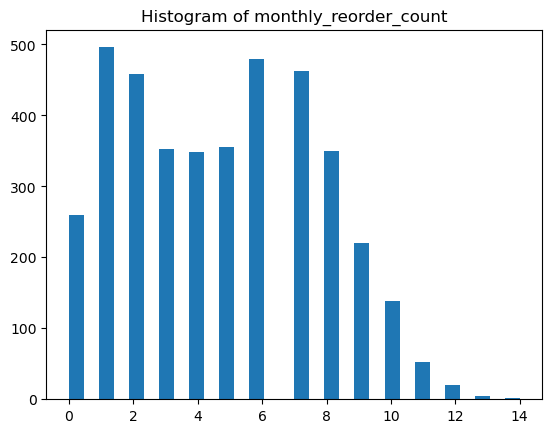

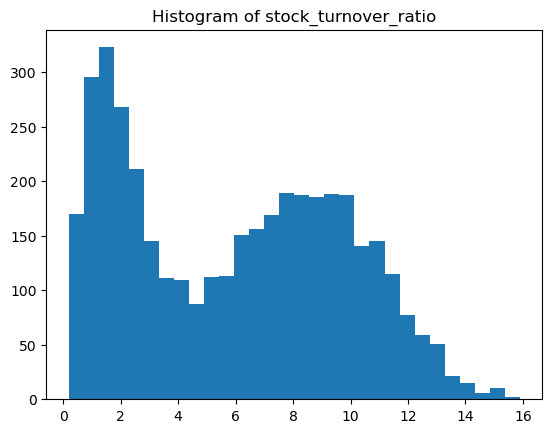

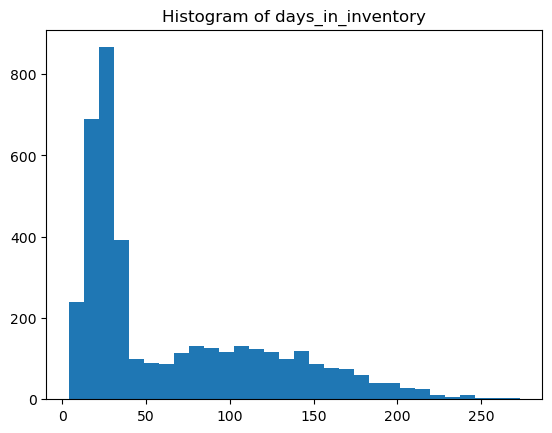

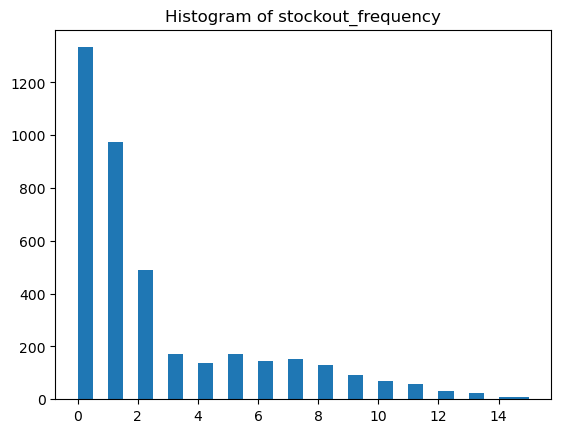

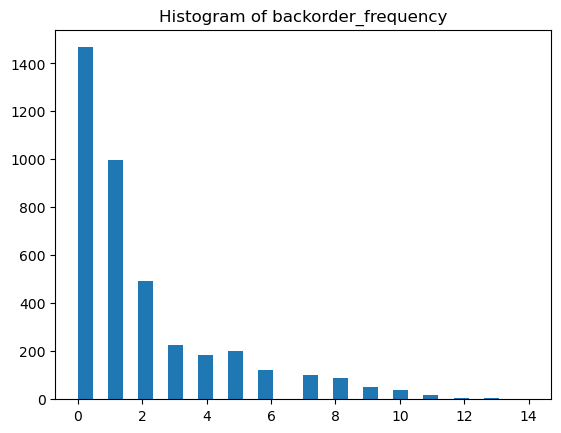

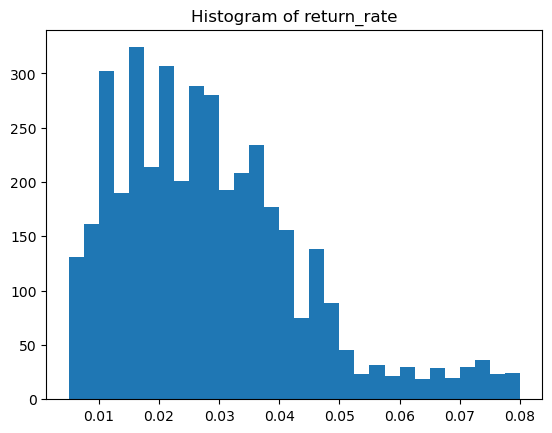

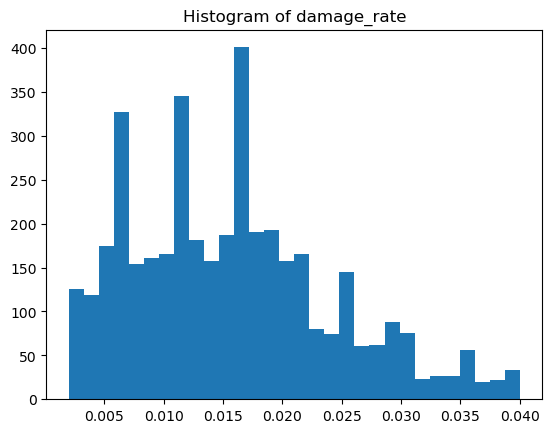

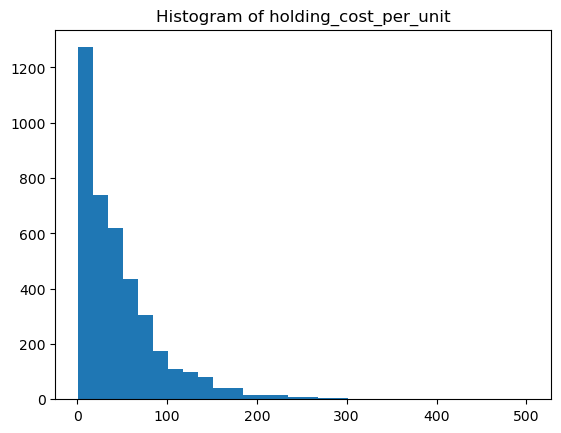

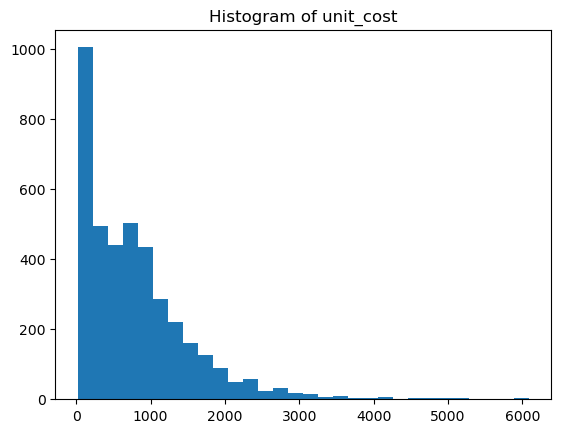

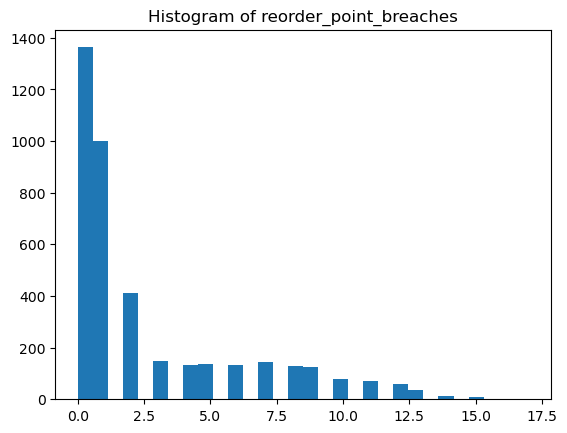

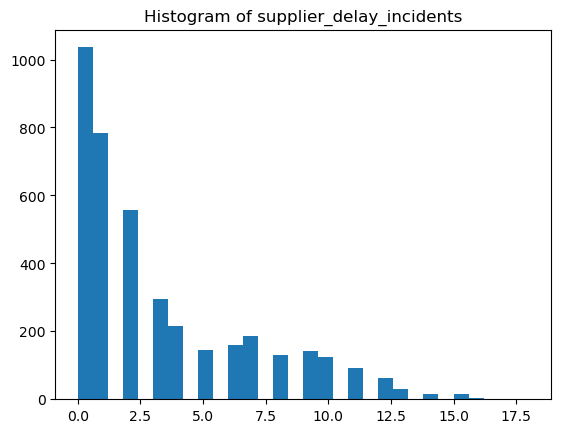

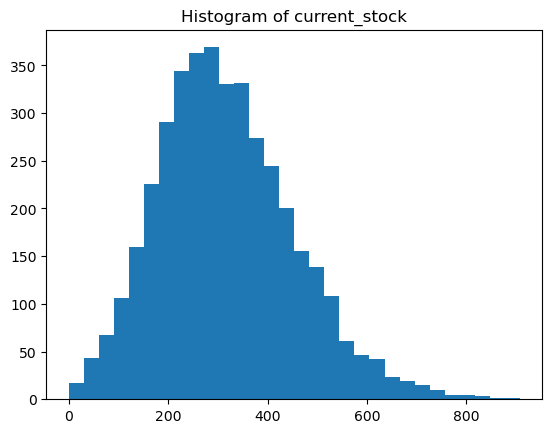

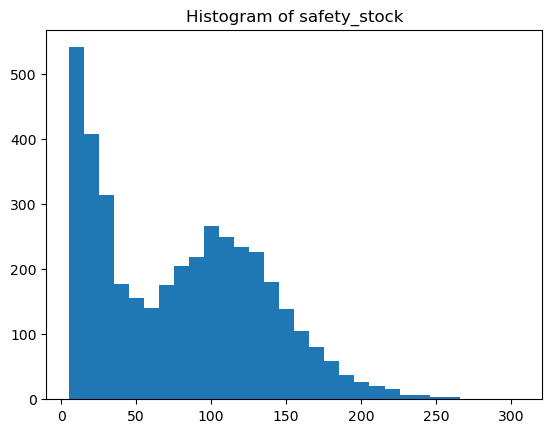

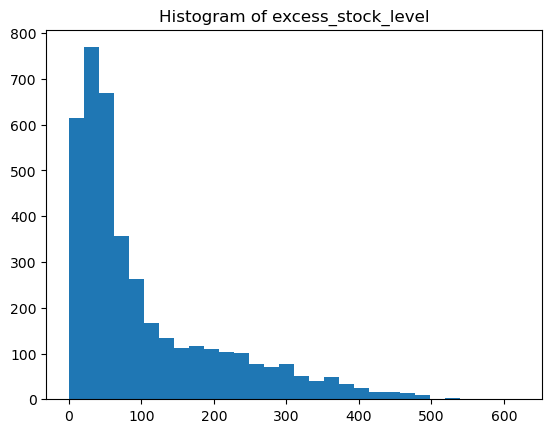

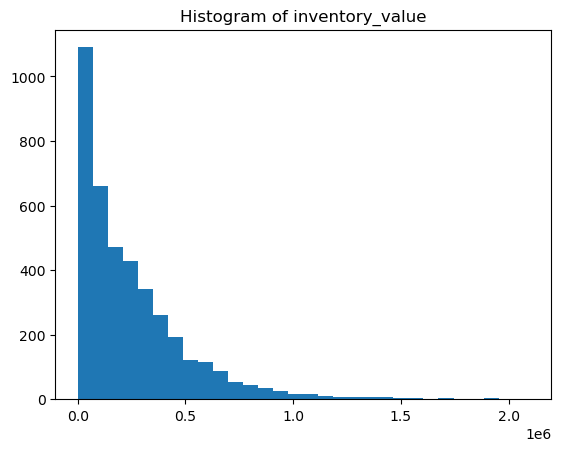

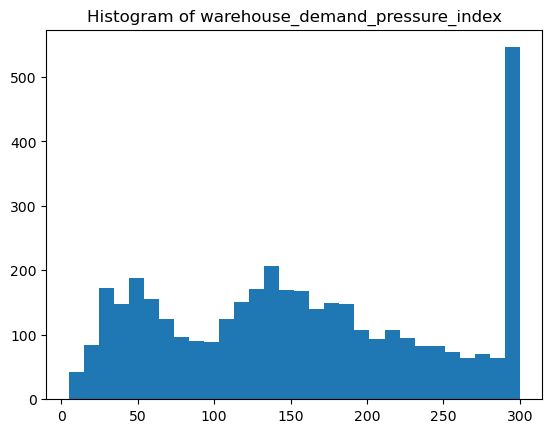

In [45]:
for col in numcol:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.show()

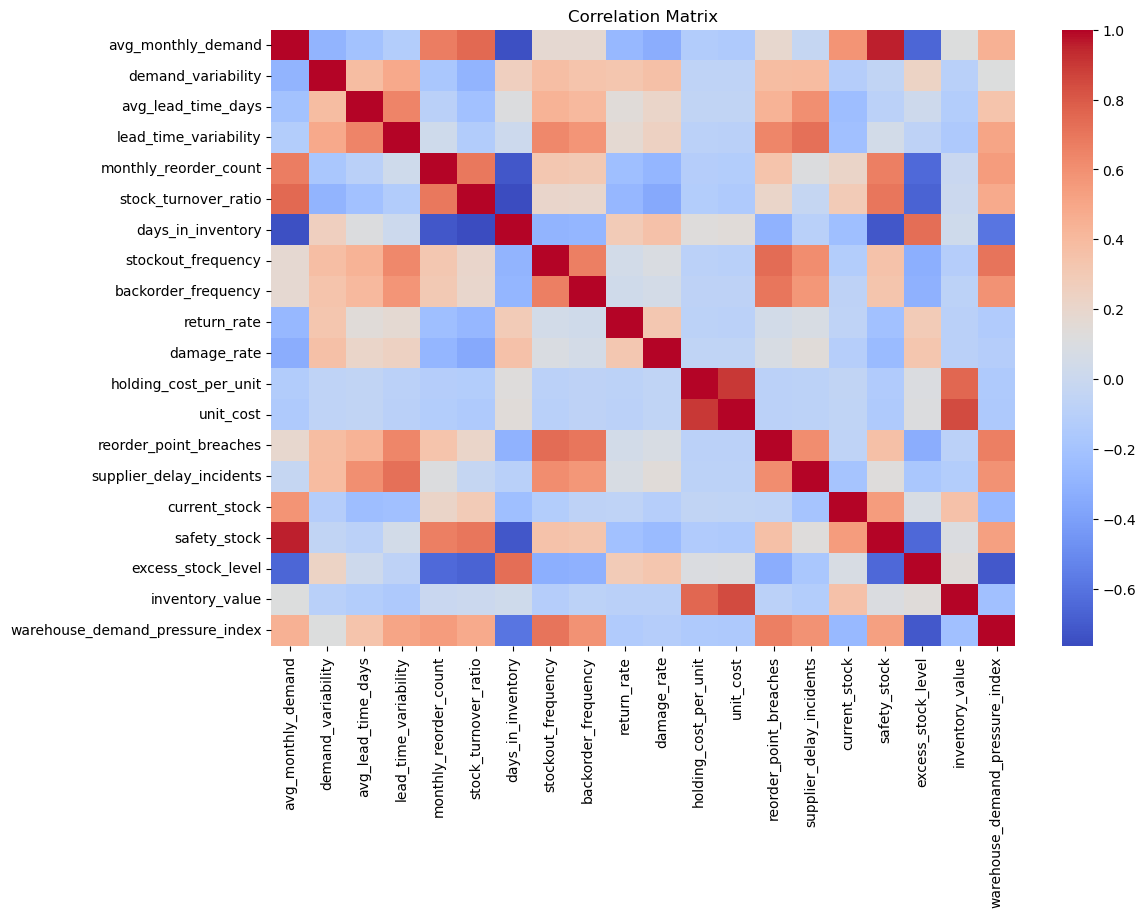

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()